# MM Decay Analysis

Notebook for multimodal missingness decay analysis on the current `training_runs` layout.
The replicate definition depends on `RETRAIN_OUTER`:

- `RETRAIN_OUTER = False`: each retained `(seed, outer_fold, inner_model_k)` predictor is treated as one trained-model replicate.
- `RETRAIN_OUTER = True`: each `(seed, outer_fold)` outer-refit model is treated as one trained-model replicate.

Configuration in the first code cell:
- `DATASET_NAME`
- `LABEL_NAME`
- `TRAIN_DEGRADING_MODALITY`
- `RETRAIN_OUTER`
- `DISTILLATION_MODEL_NAMES`: distillation methods such as `Di-PAM` and `Di-MMLP`; these are excluded from **Train-time AUPMC** and **Train degradation coefficient** because train-time missingness is applied to the student while the teacher uses complete modality information

Expected results path:
- `results/<DATASET_NAME>_<LABEL_NAME>/training_runs`
- the notebook filters runs by the `_retraintrue` / `_retrainfalse` tag in the run directory name

Implemented sections:

1. **Results visualization**
- computes replicate-level AUCs using the replicate definition implied by `RETRAIN_OUTER`
- builds mean AUC heatmaps across `(train_missing_prop, test_missing_prop)` cells
- runs a global Friedman test across models
- marks the full heatmap figure when the global Friedman test is significant

2. **Method-level metrics**
- plots the three method-level curves before displaying the tables: train-time missingness, test-time missingness, and the best-adapted envelope
- builds a method-level table with technical AUPMC metrics and degradation coefficients:
  - **Baseline AUC**: AUC at `train_missing = 0` and `test_missing = 0`
  - **Train-time AUPMC**: AUPMC over `train_missing_prop` with `test_missing_prop = 0`; distillation methods are not included
  - **Test-time AUPMC**: AUPMC over `test_missing_prop` with `train_missing_prop = 0`
  - **Best-adapted AUPMC**: AUPMC over the best-adapted envelope, defined as `max_train_missing AUC(train_missing, test_missing)` for each test missingness level
- reports three degradation coefficients obtained by dividing the method baseline by the corresponding AUPMC:
  - **Train degradation coefficient**: distillation methods are not included
  - **Test degradation coefficient**
  - **Minimum degradation coefficient**
- for distillation methods, train-time missingness in `both` conditions and in the best-adapted envelope refers to student missingness; the teacher branch receives complete modality information
- shows a second table where each metric column lists methods ordered from best to worst for that metric
- includes line plots for both raw mean AUC curves and pointwise degradation curves; in both cases the Y axis is data-adaptive

3. **Condition-level metrics**
- computes pairwise Wilcoxon signed-rank tests with Benjamini-Hochberg FDR correction inside each `(train_missing_prop, test_missing_prop)` condition
- plots pairwise significant `ΔAUC` matrices by condition, ordering methods within each panel by condition-specific mean AUC
- summarizes the top equivalent group against the first significantly lower-ranked method within each condition


In [1]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'analysis' else cwd

DATASET_NAME = 'MIMM'
LABEL_NAME = 'OS_9_label'
# DATASET_NAME = 'mmCRC'
# LABEL_NAME = 'OS_21_label'
# DATASET_NAME = '1001P'
# LABEL_NAME = 'OS_27_label'
TRAIN_DEGRADING_MODALITY = 'GLOBAL'
RETRAIN_OUTER = False
DISTILLATION_MODEL_NAMES = ['Di-PAM', 'Di-MMLP']

N_BOOTSTRAP = 2000
BOOTSTRAP_CONFIDENCE = 0.95
BOOTSTRAP_RANDOM_SEED = 42

RESULTS_TAG = f'{DATASET_NAME}_{LABEL_NAME}' if str(LABEL_NAME).strip() else DATASET_NAME
RESULTS_ROOT = PROJECT_ROOT / 'results' / RESULTS_TAG / 'training_runs'
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(
        f'Results root does not exist for dataset={DATASET_NAME!r}, label={LABEL_NAME!r}: {RESULTS_ROOT}'
    )
if not RESULTS_ROOT.is_dir():
    raise NotADirectoryError(f'Expected a directory at: {RESULTS_ROOT}')

RETRAIN_TAG = f"retrain{str(bool(RETRAIN_OUTER)).lower()}"
OUTPUT_DIR = (
    (cwd / 'MM_decay_analysis_outputs') if cwd.name == 'analysis' else (cwd / 'analysis' / 'MM_decay_analysis_outputs')
) / RESULTS_TAG / TRAIN_DEGRADING_MODALITY.lower() / RETRAIN_TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENDPOINT_NAME = LABEL_NAME if str(LABEL_NAME).strip() else RESULTS_ROOT.parent.name.replace(f'{DATASET_NAME}_', '', 1)

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/m3trics/results/MIMM_OS_9_label/training_runs')

In [2]:
import sys
import importlib
import pandas as pd

ANALYSIS_DIR = cwd if cwd.name == 'analysis' else (cwd / 'analysis')
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import results_analysis as ra
ra = importlib.reload(ra)

HAVE_MPL = ra.HAVE_MPL
resolve_requested_model_names = ra.resolve_requested_model_names
load_all_test_predictions = ra.load_all_test_predictions
expand_inner_model_predictions = ra.expand_inner_model_predictions
aggregate_member_patient_predictions = ra.aggregate_member_patient_predictions
build_replicate_auc_table = ra.build_replicate_auc_table
build_level1_summary = ra.build_level1_summary
build_method_plot_summary = ra.build_method_plot_summary
build_method_level_metrics = ra.build_method_level_metrics
build_degradation_curve_summary = ra.build_degradation_curve_summary
build_metric_ordering_table = ra.build_metric_ordering_table
plot_method_line_triplet = ra.plot_method_line_triplet
compute_level1_global_friedman = ra.compute_level1_global_friedman
plot_level1_auc_heatmaps = ra.plot_level1_auc_heatmaps
compute_level2_pairwise_tests = ra.compute_level2_pairwise_tests
select_level2_plot_pairs = ra.select_level2_plot_pairs
plot_level2_significant_pairs_heatmap = ra.plot_level2_significant_pairs_heatmap
plot_level3_pairwise_condition_matrices = ra.plot_level3_pairwise_condition_matrices


## Results visualization

Mean AUC heatmaps across train/test missingness conditions, with a global Friedman test across models.

Each heatmap cell reports `mean AUC ± 95% CI`. A `*` at the figure level indicates that the global Friedman test is significant (`p < 0.05`).


In [3]:
REQUESTED_MODEL_NAMES = resolve_requested_model_names(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_degrading_modality=TRAIN_DEGRADING_MODALITY,
    retrain_outer=RETRAIN_OUTER,
)
if not REQUESTED_MODEL_NAMES:
    raise ValueError('No model folders were detected for the requested dataset / location / retrain flag.')

raw_predictions_df, missing_prediction_files = load_all_test_predictions(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_degrading_modality=TRAIN_DEGRADING_MODALITY,
    model_names=REQUESTED_MODEL_NAMES,
    retrain_outer=RETRAIN_OUTER,
)
if raw_predictions_df.empty:
    raise ValueError('No test_predictions.csv files with retained inner-model probabilities were found.')

member_prediction_df = expand_inner_model_predictions(raw_predictions_df)
member_patient_df = aggregate_member_patient_predictions(member_prediction_df)
replicate_auc_df = build_replicate_auc_table(member_patient_df)
level1_summary_df = build_level1_summary(replicate_auc_df=replicate_auc_df)
level1_global_friedman_df = compute_level1_global_friedman(level1_summary_df)
method_plot_summary_df = build_method_plot_summary(
    replicate_auc_df=replicate_auc_df,
    n_bootstrap=N_BOOTSTRAP,
    confidence=BOOTSTRAP_CONFIDENCE,
    random_seed=BOOTSTRAP_RANDOM_SEED,
)
degradation_curve_summary_df = build_degradation_curve_summary(
    method_plot_summary_df=method_plot_summary_df,
    distillation_model_names=DISTILLATION_MODEL_NAMES,
)
method_level_metrics_df, post_adaptation_envelope_df = build_method_level_metrics(
    replicate_auc_df=replicate_auc_df,
    level1_df=level1_summary_df,
    distillation_model_names=DISTILLATION_MODEL_NAMES,
)
method_metric_ordering_df = build_metric_ordering_table(
    method_level_metrics_df,
    distillation_model_names=DISTILLATION_MODEL_NAMES,
)

replicate_auc_path = OUTPUT_DIR / 'replicate_auc_table.csv'
method_condition_summary_path = OUTPUT_DIR / 'method_condition_mean_auc_summary.csv'
level1_global_friedman_path = OUTPUT_DIR / 'level1_global_friedman.csv'
method_plot_summary_path = OUTPUT_DIR / 'method_plot_summary.csv'
degradation_curve_summary_path = OUTPUT_DIR / 'degradation_curve_summary.csv'
method_level_metrics_path = OUTPUT_DIR / 'method_level_metrics.csv'
method_metric_ordering_path = OUTPUT_DIR / 'method_metric_orderings.csv'
post_adaptation_envelope_path = OUTPUT_DIR / 'resilience_post_adaptation_envelope.csv'

replicate_auc_df.to_csv(replicate_auc_path, index=False)
level1_summary_df.to_csv(method_condition_summary_path, index=False)
level1_global_friedman_df.to_csv(level1_global_friedman_path, index=False)
method_plot_summary_df.to_csv(method_plot_summary_path, index=False)
degradation_curve_summary_df.to_csv(degradation_curve_summary_path, index=False)
method_level_metrics_df.to_csv(method_level_metrics_path, index=False)
method_metric_ordering_df.to_csv(method_metric_ordering_path, index=False)
post_adaptation_envelope_df.to_csv(post_adaptation_envelope_path, index=False)

replicate_unit_label = 'seed x outer_fold' if bool(RETRAIN_OUTER) else 'seed x outer_fold x inner_model_k'
print(f'Replicate unit: {replicate_unit_label}')
print('Saved:', replicate_auc_path)
print('Saved:', method_condition_summary_path)
print('Saved:', level1_global_friedman_path)
print('Saved:', method_plot_summary_path)
print('Saved:', degradation_curve_summary_path)
print('Saved:', method_level_metrics_path)
print('Saved:', method_metric_ordering_path)
print('Saved:', post_adaptation_envelope_path)


Replicate unit: seed x outer_fold x inner_model_k
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/replicate_auc_table.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/method_condition_mean_auc_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/level1_global_friedman.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/method_plot_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/degradation_curve_summary.csv
Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/method_level_metrics.csv
Saved: /Users/marcalbesa/Desktop/TFM/g

Global Friedman test across heatmap cells:


,n_cells,n_models,friedman_statistic,p_value,significant_p0_05
0,25,8,102.638876,3.073492e-19,True


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/figures/level1_8models.png


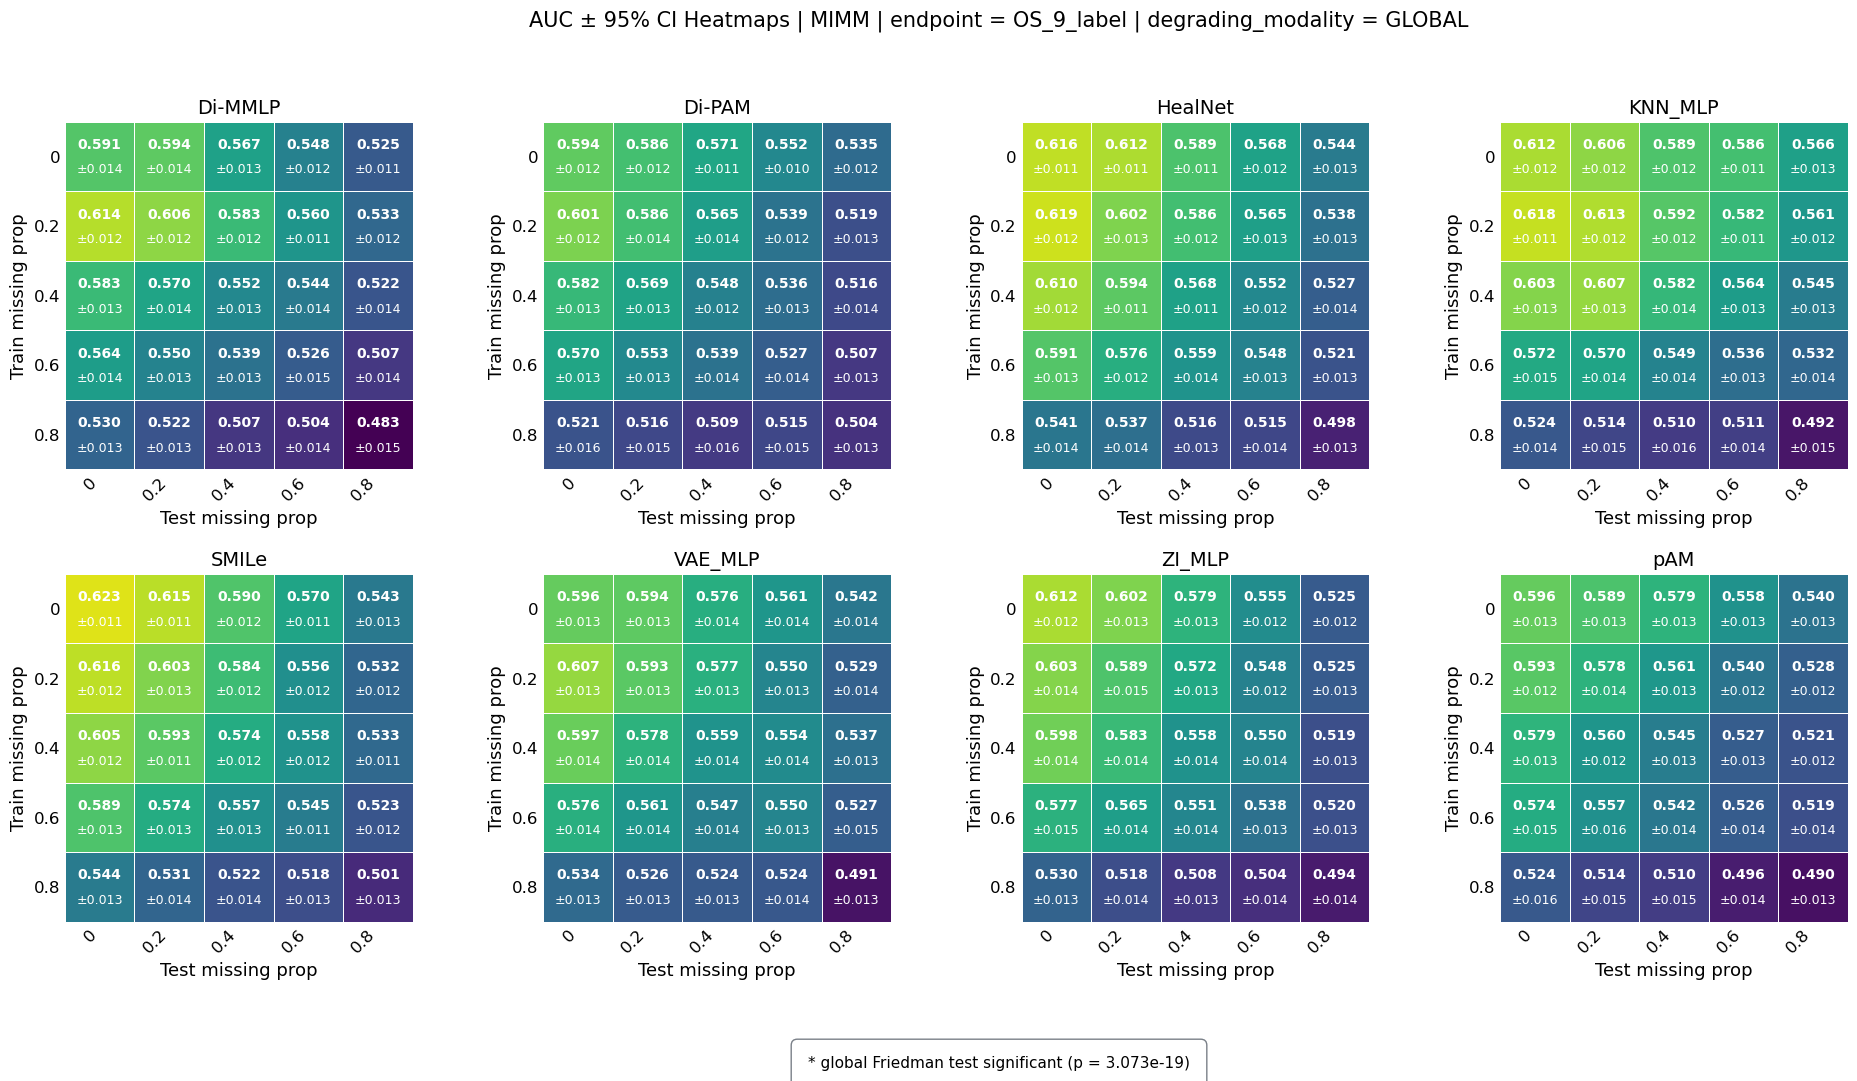

In [4]:
print('Global Friedman test across heatmap cells:')
display(level1_global_friedman_df)

level1_model_count_tag = f"{level1_summary_df['model_name'].nunique()}models" if not level1_summary_df.empty else '0models'
if HAVE_MPL:
    plot_level1_auc_heatmaps(
        summary_df=method_plot_summary_df,
        friedman_global_df=level1_global_friedman_df,
        title=f'AUC ± 95% CI Heatmaps | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_DEGRADING_MODALITY}',
        figures_dir=FIGURES_DIR,
        file_name=f'level1_{level1_model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping level 1 heatmap plot.')


## Method-level metrics

The method-level section first plots the curves and then reports the numerical metrics derived from those curves. This makes the relationship between the visual trajectory and the final scalar summary explicit.

`Baseline AUC` is the AUC obtained when both training and test data are complete (`train_missing_prop = 0`, `test_missing_prop = 0`).

`Train-time AUPMC` is the normalized area under the performance-missingness curve across train-time missingness while test data remain complete. It summarizes the curve `AUC(m_train, 0)`. Distillation methods listed in `DISTILLATION_MODEL_NAMES` are excluded from this metric because the teacher uses complete modality information while missingness is applied to the student.

`Test-time AUPMC` is the normalized area under the curve `AUC(0, m_test)`. It measures performance when the model is trained on complete data and evaluated under increasing test-time missingness.

`Best-adapted AUPMC` is the normalized area under the best-adapted envelope. For each test missingness level, the envelope keeps the best AUC obtained across all train-time missingness levels, summarizing the best achievable performance after selecting the training missingness regime.

The degradation coefficients divide the method baseline AUC by each AUPMC. Values close to 1 indicate that the curve preserves baseline performance on average, values above 1 indicate relative degradation, and values below 1 indicate improvement relative to the complete-data baseline. Lower degradation coefficients are therefore better. `Train degradation coefficient` is also excluded for distillation methods for the same reason as `Train-time AUPMC`.

The line plots show both the raw mean AUC curves and pointwise degradation curves. The degradation curves are computed as `baseline AUC / AUC(missingness condition)`, so the first point is 1 by definition when the baseline cell is available. These curves provide the visual counterpart of the scalar degradation coefficients.

For `Di-PAM` and `Di-MMLP`, train-time missingness in `both` conditions and in the best-adapted envelope should be interpreted as student missingness. The teacher branch receives complete modality information.


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/figures/method_level_mean_auc_curves_MIMM_OS_9_label_global.png


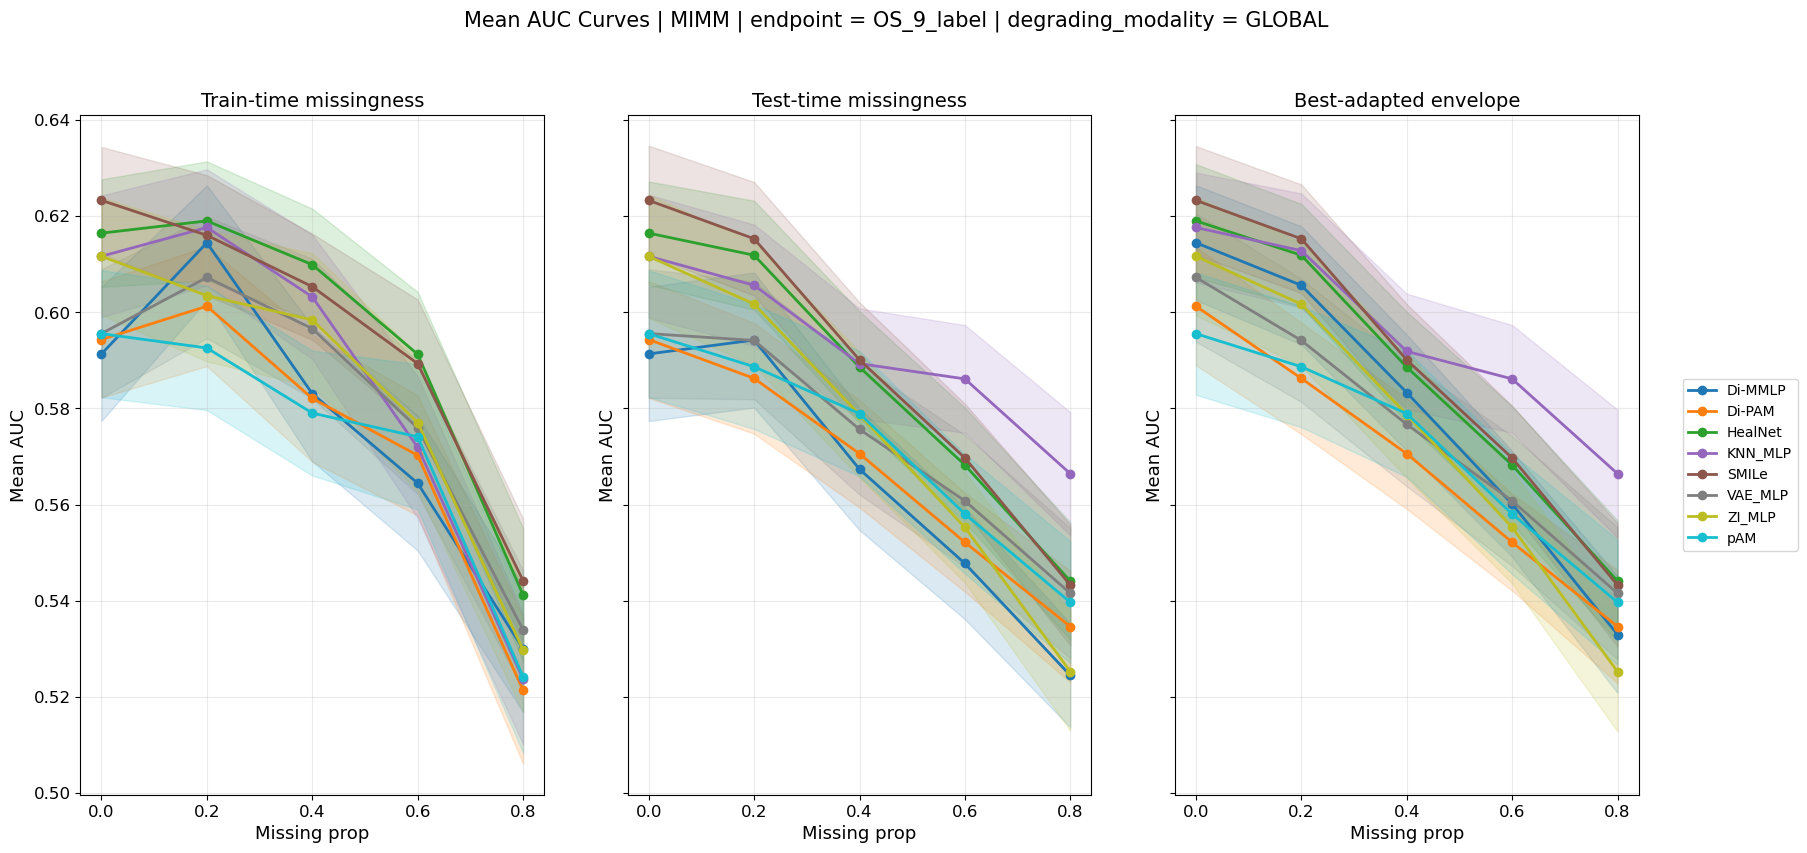

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/figures/method_level_degradation_curves_MIMM_OS_9_label_global.png


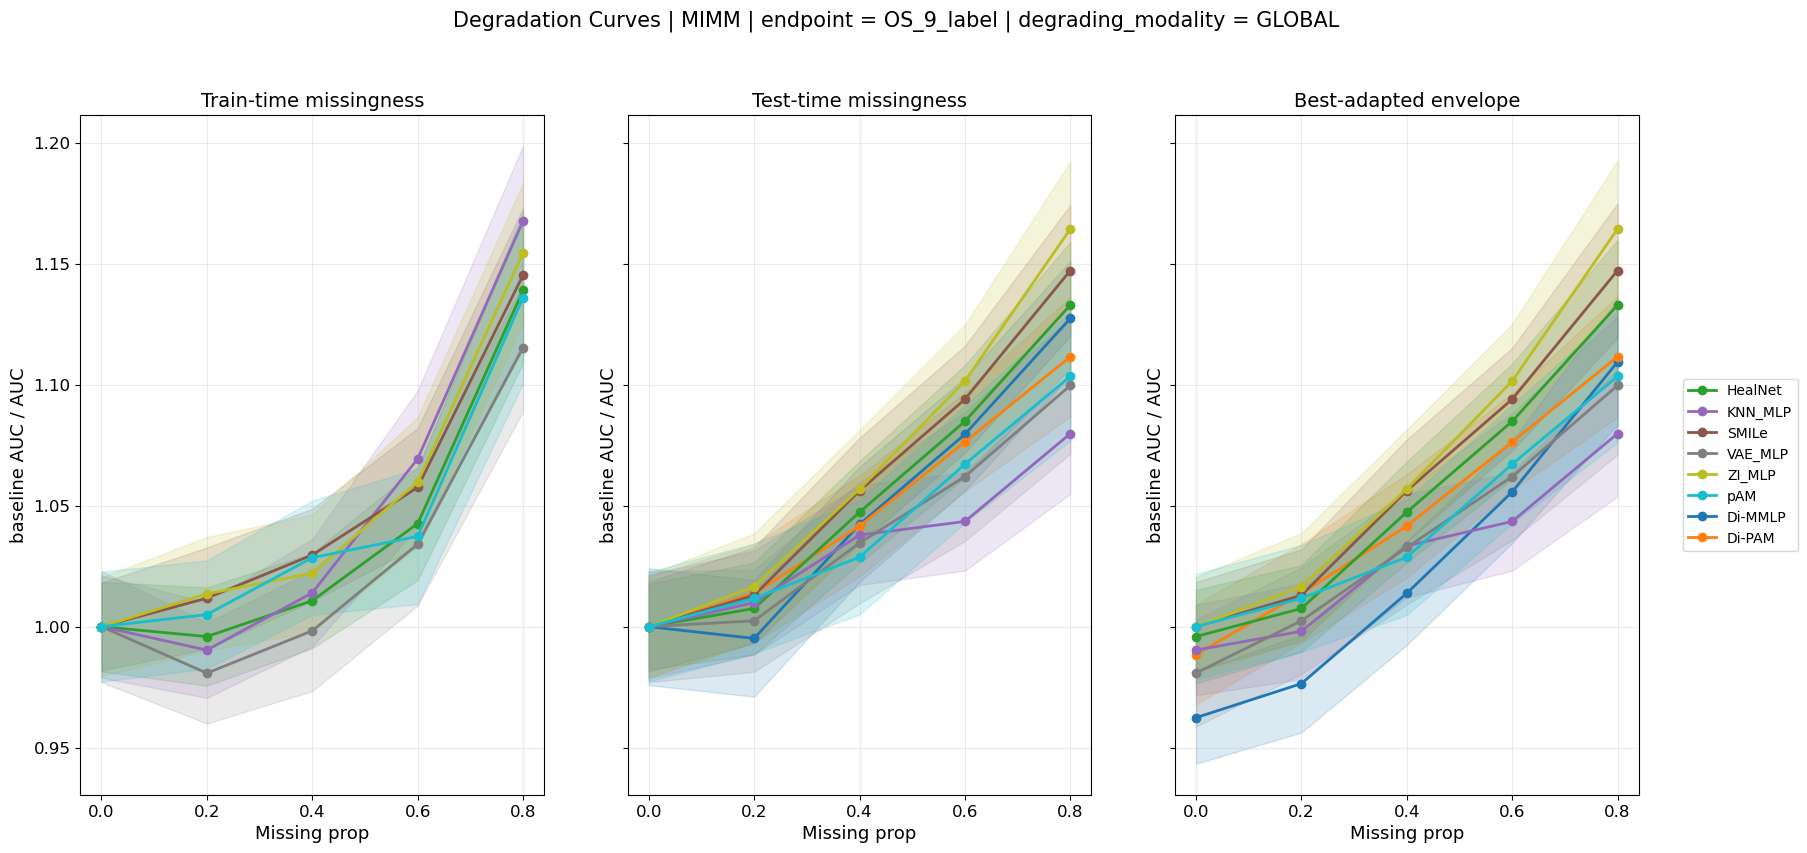

Distillation methods excluded from Train-time AUPMC and Train degradation coefficient: Di-PAM, Di-MMLP
For distillation methods, train missingness in both/best-adapted settings refers to student missingness.
Method-level metrics:


,Model,Distillation method,Baseline AUC,Train-time AUPMC,Train degradation coefficient,Test-time AUPMC,Test degradation coefficient,Best-adapted AUPMC,Minimum degradation coefficient
0,SMILe,False,0.6233,0.5986,1.0412,0.5896,1.0571,0.5896,1.0571
1,HealNet,False,0.6165,0.5997,1.0279,0.5872,1.0498,0.5876,1.0492
2,KNN_MLP,False,0.6116,0.5901,1.0365,0.5925,1.0323,0.5957,1.0267
3,ZI_MLP,False,0.6116,0.5874,1.0412,0.5760,1.0618,0.5760,1.0618
4,VAE_MLP,False,0.5956,0.5861,1.0161,0.5748,1.0362,0.5765,1.0331
5,pAM,False,0.5955,0.5764,1.0332,0.5733,1.0388,0.5733,1.0388
6,Di-PAM,True,0.5943,NaN,NaN,0.5684,1.0457,0.5692,1.0441
7,Di-MMLP,True,0.5913,NaN,NaN,0.5668,1.0433,0.5807,1.0183


Methods ordered by metric:


,Baseline AUC,Train-time AUPMC,Train degradation coefficient,Test-time AUPMC,Test degradation coefficient,Best-adapted AUPMC,Minimum degradation coefficient
0,SMILe,HealNet,VAE_MLP,KNN_MLP,KNN_MLP,KNN_MLP,Di-MMLP
1,HealNet,SMILe,HealNet,SMILe,VAE_MLP,SMILe,KNN_MLP
2,KNN_MLP,KNN_MLP,pAM,HealNet,pAM,HealNet,VAE_MLP
3,ZI_MLP,ZI_MLP,KNN_MLP,ZI_MLP,Di-MMLP,Di-MMLP,pAM
4,VAE_MLP,VAE_MLP,SMILe,VAE_MLP,Di-PAM,VAE_MLP,Di-PAM
5,pAM,pAM,ZI_MLP,pAM,HealNet,ZI_MLP,HealNet
6,Di-PAM,,,Di-PAM,SMILe,pAM,SMILe
7,Di-MMLP,,,Di-MMLP,ZI_MLP,Di-PAM,ZI_MLP


In [5]:
if HAVE_MPL:
    plot_method_line_triplet(
        summary_df=method_plot_summary_df,
        metric_col='mean_auc',
        title=f'Mean AUC Curves | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_DEGRADING_MODALITY}',
        ylabel='Mean AUC',
        figures_dir=FIGURES_DIR,
        file_name=f'method_level_mean_auc_curves_{RESULTS_TAG}_{TRAIN_DEGRADING_MODALITY.lower()}.png',
        panel_titles={
            'train': 'Train-time missingness',
            'test': 'Test-time missingness',
            'envelope': 'Best-adapted envelope',
        },
        y_limits=None,
        clip_ci=False,
    )
    plot_method_line_triplet(
        summary_df=degradation_curve_summary_df,
        metric_col='degradation_ratio',
        title=f'Degradation Curves | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_DEGRADING_MODALITY}',
        ylabel='baseline AUC / AUC',
        figures_dir=FIGURES_DIR,
        file_name=f'method_level_degradation_curves_{RESULTS_TAG}_{TRAIN_DEGRADING_MODALITY.lower()}.png',
        ci_col='degradation_ratio_ci95',
        panel_titles={
            'train': 'Train-time missingness',
            'test': 'Test-time missingness',
            'envelope': 'Best-adapted envelope',
        },
        y_limits=None,
        clip_ci=False,
    )
else:
    print('Matplotlib not available; skipping method-level line plots.')

method_level_display_df = (
    method_level_metrics_df[[
        'model_name',
        'is_distillation_method',
        'baseline_auc',
        'train_time_aupmc',
        'train_degradation_coefficient',
        'test_time_aupmc',
        'test_degradation_coefficient',
        'best_adapted_aupmc',
        'minimum_degradation_coefficient',
    ]]
    .rename(columns={
        'model_name': 'Model',
        'is_distillation_method': 'Distillation method',
        'baseline_auc': 'Baseline AUC',
        'train_time_aupmc': 'Train-time AUPMC',
        'train_degradation_coefficient': 'Train degradation coefficient',
        'test_time_aupmc': 'Test-time AUPMC',
        'test_degradation_coefficient': 'Test degradation coefficient',
        'best_adapted_aupmc': 'Best-adapted AUPMC',
        'minimum_degradation_coefficient': 'Minimum degradation coefficient',
    })
)

configured_distillation_models = [
    model for model in DISTILLATION_MODEL_NAMES
    if model in set(method_level_metrics_df['model_name'].astype(str))
]
if configured_distillation_models:
    print(
        'Distillation methods excluded from Train-time AUPMC and Train degradation coefficient: '
        + ', '.join(configured_distillation_models)
    )
    print('For distillation methods, train missingness in both/best-adapted settings refers to student missingness.')

print('Method-level metrics:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    display(method_level_display_df.round(4))

print('Methods ordered by metric:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000):
    display(method_metric_ordering_df)


## Condition-level metrics

Pairwise significant `ΔAUC` matrices by missingness condition.
Within each panel, methods are ordered by condition-specific mean AUC, so rank positions may change from one condition to another.
Only pairs that remain significant after Wilcoxon signed-rank testing with Benjamini-Hochberg FDR correction are highlighted.


Saved: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/wilcoxon_significant.csv
Significant pairwise comparisons: 125
Condition-summary heatmap cells: 19
Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/figures/level2_pairwise_condition_matrices_MIMM_OS_9_label_global_8models.png


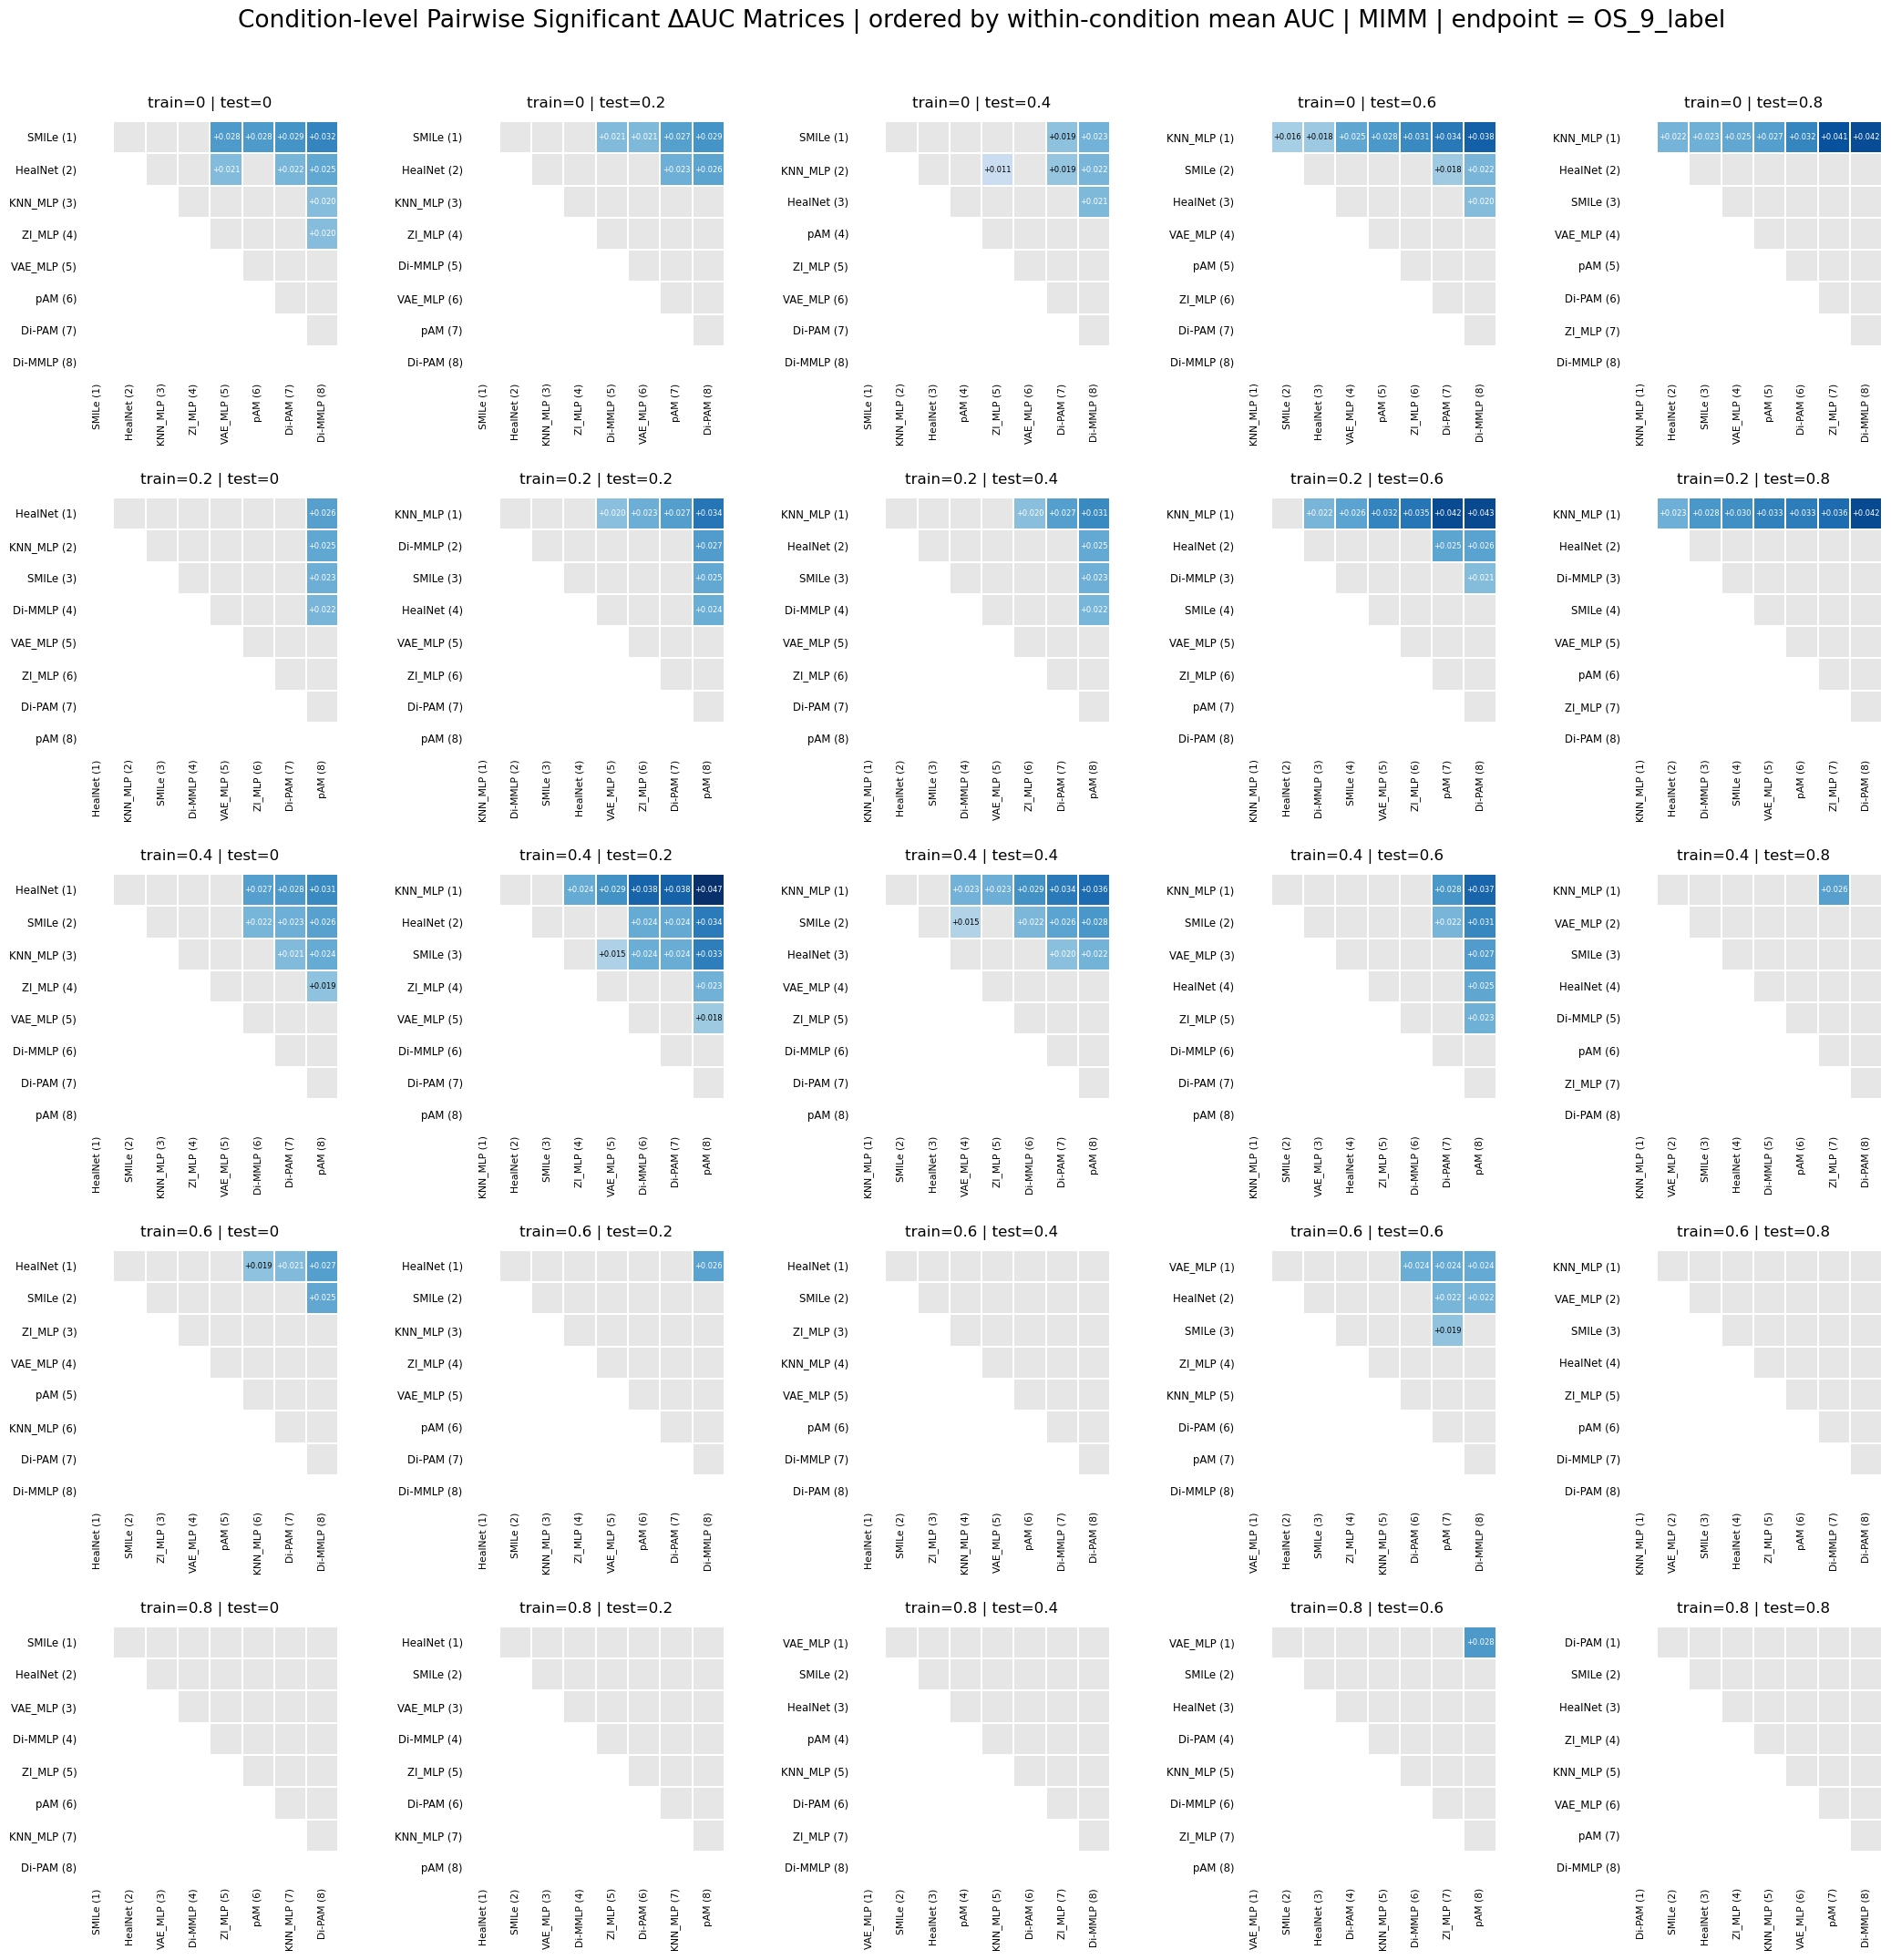

In [6]:
level2_pairwise_df = compute_level2_pairwise_tests(
    level1_df=level1_summary_df,
    replicate_auc_df=replicate_auc_df,
)
level2_plot_df = select_level2_plot_pairs(level2_pairwise_df)

root_tag = RESULTS_ROOT.parent.name
location_tag = TRAIN_DEGRADING_MODALITY.lower()
model_count_tag = f"{level1_summary_df['model_name'].nunique()}models" if not level1_summary_df.empty else '0models'

level2_significant_pairs_df = (
    level2_pairwise_df.loc[level2_pairwise_df['significant_fdr_0p05']]
    .sort_values(['winner_model', 'loser_model', 'train_missing_prop', 'test_missing_prop'])
    .reset_index(drop=True)
)

level2_significant_path = OUTPUT_DIR / 'wilcoxon_significant.csv'
level2_significant_pairs_df.to_csv(level2_significant_path, index=False)
print('Saved:', level2_significant_path)
print('Significant pairwise comparisons:', len(level2_significant_pairs_df))
print('Condition-summary heatmap cells:', len(level2_plot_df))

if HAVE_MPL:
    plot_level3_pairwise_condition_matrices(
        level2_pairwise_df=level2_pairwise_df,
        title=f'Condition-level Pairwise Significant ΔAUC Matrices | ordered by within-condition mean AUC | {DATASET_NAME} | endpoint = {ENDPOINT_NAME}',
        figures_dir=FIGURES_DIR,
        file_name=f'level2_pairwise_condition_matrices_{root_tag}_{location_tag}_{model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping condition-level pairwise ΔAUC matrices.')



### Top equivalent group vs first significantly lower-ranked method

Condition-level summary heatmap derived from the same Wilcoxon signed-rank + FDR results.
Each cell shows the top equivalent group of methods that are all significantly better than the first lower-ranked loser; the number in parentheses gives the loser position in the within-condition mean-AUC ranking.


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/m3trics/analysis/MM_decay_analysis_outputs/MIMM_OS_9_label/global/retrainfalse/figures/level3_significant_pairs_MIMM_OS_9_label_global_8models.png


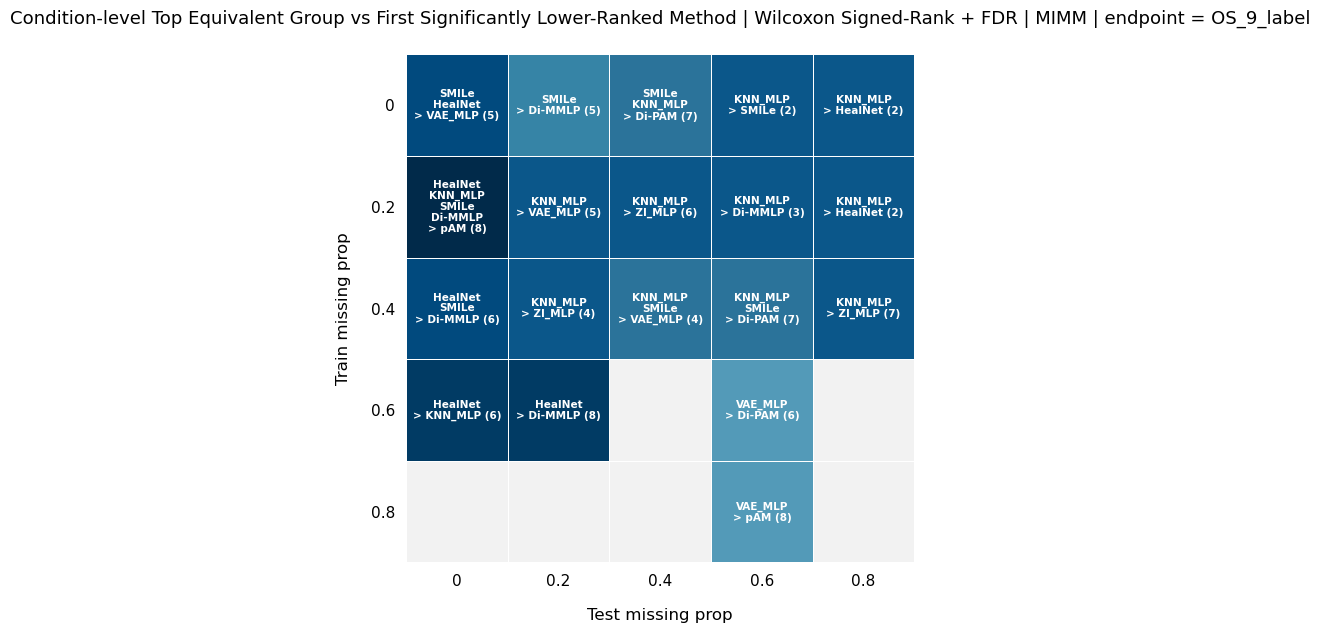

In [7]:
if HAVE_MPL:
    plot_level2_significant_pairs_heatmap(
        level2_plot_df=level2_plot_df,
        title=f'Condition-level Top Equivalent Group vs First Significantly Lower-Ranked Method | Wilcoxon Signed-Rank + FDR | {DATASET_NAME} | endpoint = {ENDPOINT_NAME}',
        figures_dir=FIGURES_DIR,
        file_name=f'level3_significant_pairs_{root_tag}_{location_tag}_{model_count_tag}.png',
    )
else:
    print('Matplotlib not available; skipping condition-level summary heatmap.')
